# mpg

In [1]:
import seaborn as sns
import pandas as pd
from matplotlib import pyplot as plt
%matplotlib inline

In [2]:
df = sns.load_dataset('mpg')

In [3]:
print(type(df))

<class 'pandas.core.frame.DataFrame'>


In [4]:
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino


In [5]:
df.tail()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
393,27.0,4,140.0,86.0,2790,15.6,82,usa,ford mustang gl
394,44.0,4,97.0,52.0,2130,24.6,82,europe,vw pickup
395,32.0,4,135.0,84.0,2295,11.6,82,usa,dodge rampage
396,28.0,4,120.0,79.0,2625,18.6,82,usa,ford ranger
397,31.0,4,119.0,82.0,2720,19.4,82,usa,chevy s-10


In [6]:
print(df.shape)

(398, 9)


In [7]:
df.describe()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year
count,398.000000,398.000000,398.000000,392.000000,398.000000,398.000000,398.000000
mean,23.514573,5.454774,193.425879,104.469388,2970.424623,15.568090,76.010050
std,7.815984,1.701004,104.269838,38.491160,846.841774,2.757689,3.697627
min,9.000000,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000
25%,17.500000,4.000000,104.250000,75.000000,2223.750000,13.825000,73.000000
50%,23.000000,4.000000,148.500000,93.500000,2803.500000,15.500000,76.000000
75%,29.000000,8.000000,262.000000,126.000000,3608.000000,17.175000,79.000000
max,46.600000,8.000000,455.000000,230.000000,5140.000000,24.800000,82.000000


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model_year    398 non-null    int64  
 7   origin        398 non-null    object 
 8   name          398 non-null    object 
dtypes: float64(4), int64(3), object(2)
memory usage: 28.1+ KB


In [9]:
df.isnull().sum()

mpg             0
cylinders       0
displacement    0
horsepower      6
weight          0
acceleration    0
model_year      0
origin          0
name            0
dtype: int64

In [10]:
df.dropna(inplace=True)

In [11]:
df.isnull().sum()

mpg             0
cylinders       0
displacement    0
horsepower      0
weight          0
acceleration    0
model_year      0
origin          0
name            0
dtype: int64

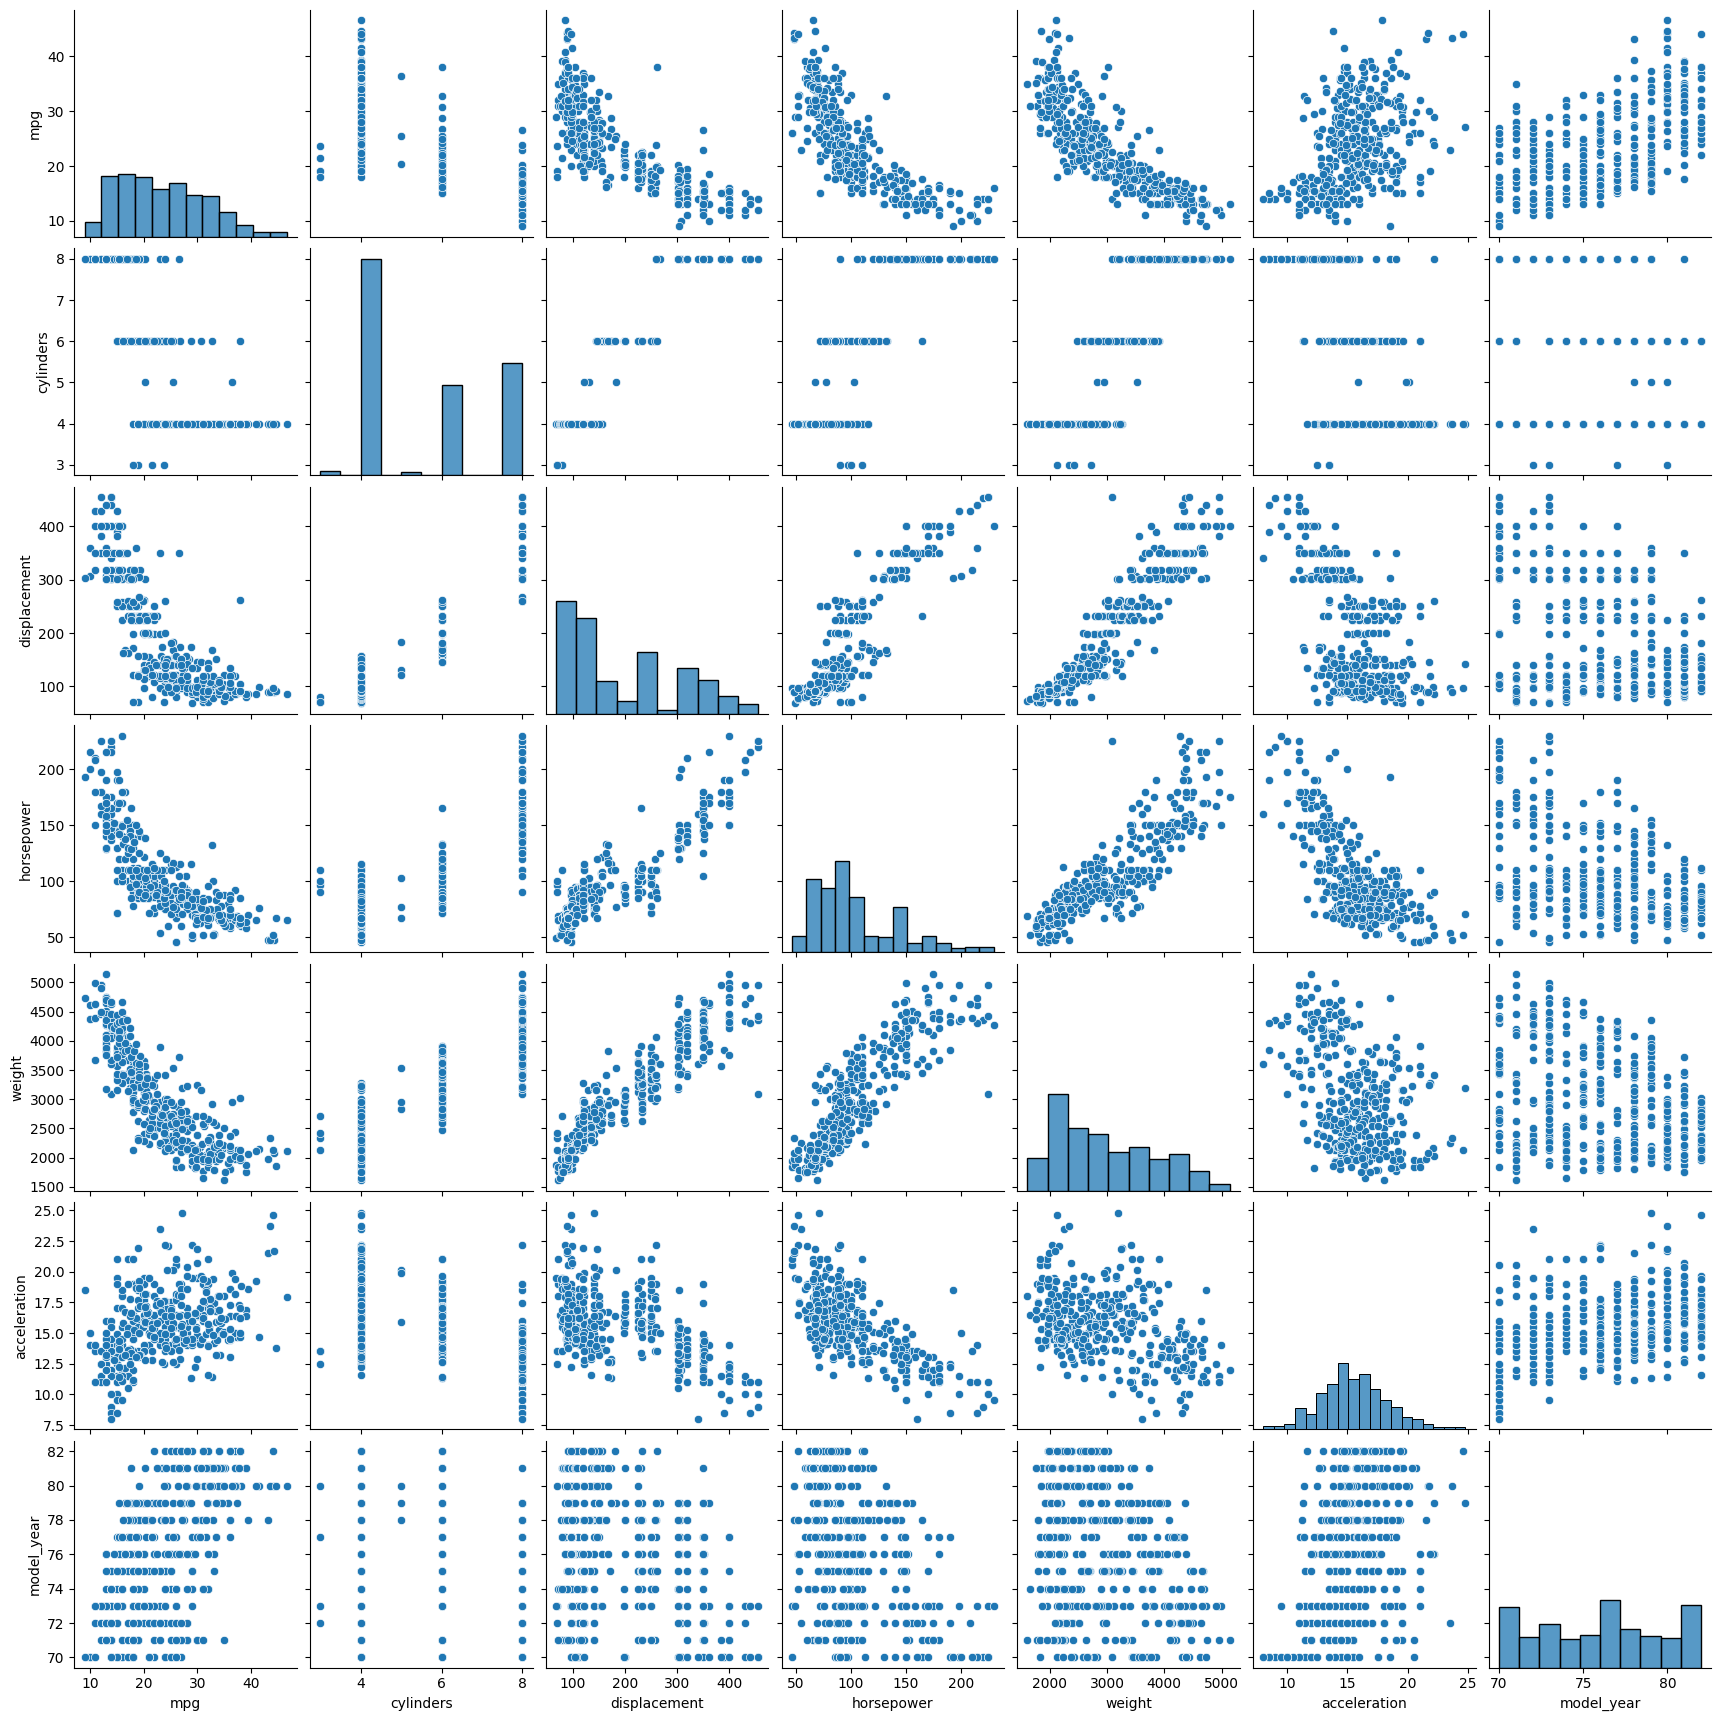

In [12]:
sns.pairplot(df)

<Axes: xlabel='origin', ylabel='mpg'>

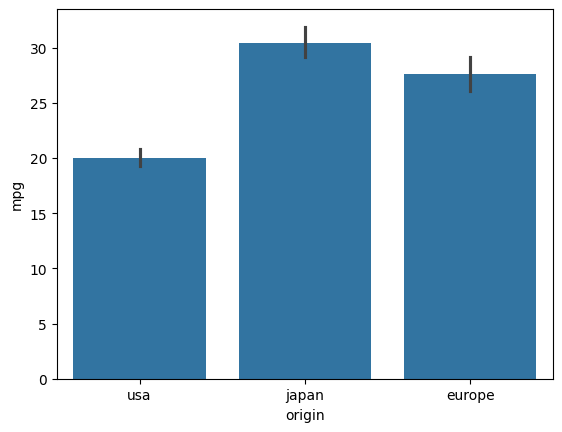

In [13]:
sns.barplot(x='origin', y='mpg', data=df)

<Axes: xlabel='cylinders', ylabel='mpg'>

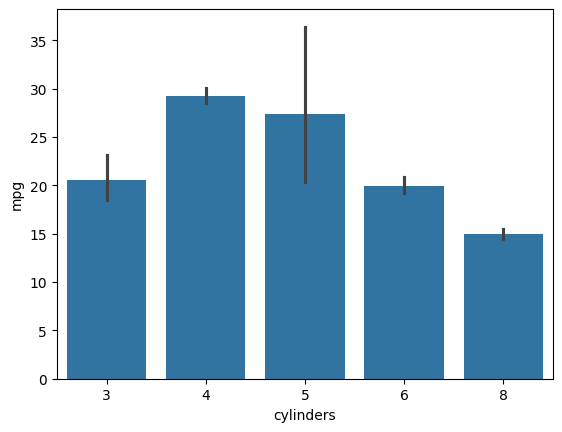

In [14]:
sns.barplot(x='cylinders', y='mpg', data=df)

In [15]:
import pandas as pd

def agg_func(col):
    if pd.api.types.is_categorical_dtype(col) or pd.api.types.is_object_dtype(col):
        return 'count'
    elif pd.api.types.is_numeric_dtype(col):
        return 'mean'
    else:
        return 'first'

In [16]:
columns_to_agg = [col for col in df.columns if col != 'origin']

groupedvalues = df.groupby('origin').agg({col: agg_func(df[col]) for col in columns_to_agg}).reset_index()
groupedvalues.head()

/tmp/ipykernel_15507/594790445.py:4: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(col) or pd.api.types.is_object_dtype(col):


,origin,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,name
0,europe,27.602941,4.161765,109.632353,80.558824,2433.470588,16.794118,75.676471,68
1,japan,30.450633,4.101266,102.708861,79.835443,2221.227848,16.172152,77.443038,79
2,usa,20.033469,6.277551,247.512245,119.048980,3372.489796,14.990204,75.591837,245


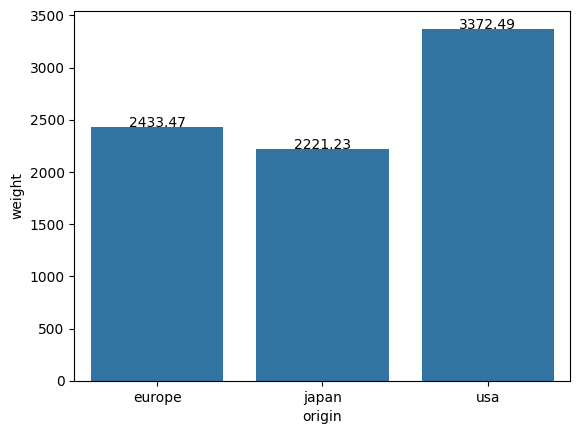

In [17]:
g = sns.barplot(x='origin',y='weight',data=groupedvalues)

for index, row in groupedvalues.iterrows():
    g.text(row.name, row.weight, round(row.weight, 2), color='black', ha="center")

In [18]:
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino


In [22]:
df.drop('name', axis=1, inplace=True)

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 392 entries, 0 to 397
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           392 non-null    float64
 1   cylinders     392 non-null    int64  
 2   displacement  392 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        392 non-null    int64  
 5   acceleration  392 non-null    float64
 6   model_year    392 non-null    int64  
 7   origin        392 non-null    object 
dtypes: float64(4), int64(3), object(1)
memory usage: 27.6+ KB


In [24]:
print(df.origin.unique())

['usa' 'japan' 'europe']


In [25]:
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()

dfi = df.copy()

dfi['origin'] = label_encoder.fit_transform(dfi['origin'])
print(label_encoder.classes_)

['europe' 'japan' 'usa']


In [26]:
dfi.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin
0,18.0,8,307.0,130.0,3504,12.0,70,2
1,15.0,8,350.0,165.0,3693,11.5,70,2
2,18.0,8,318.0,150.0,3436,11.0,70,2
3,16.0,8,304.0,150.0,3433,12.0,70,2
4,17.0,8,302.0,140.0,3449,10.5,70,2


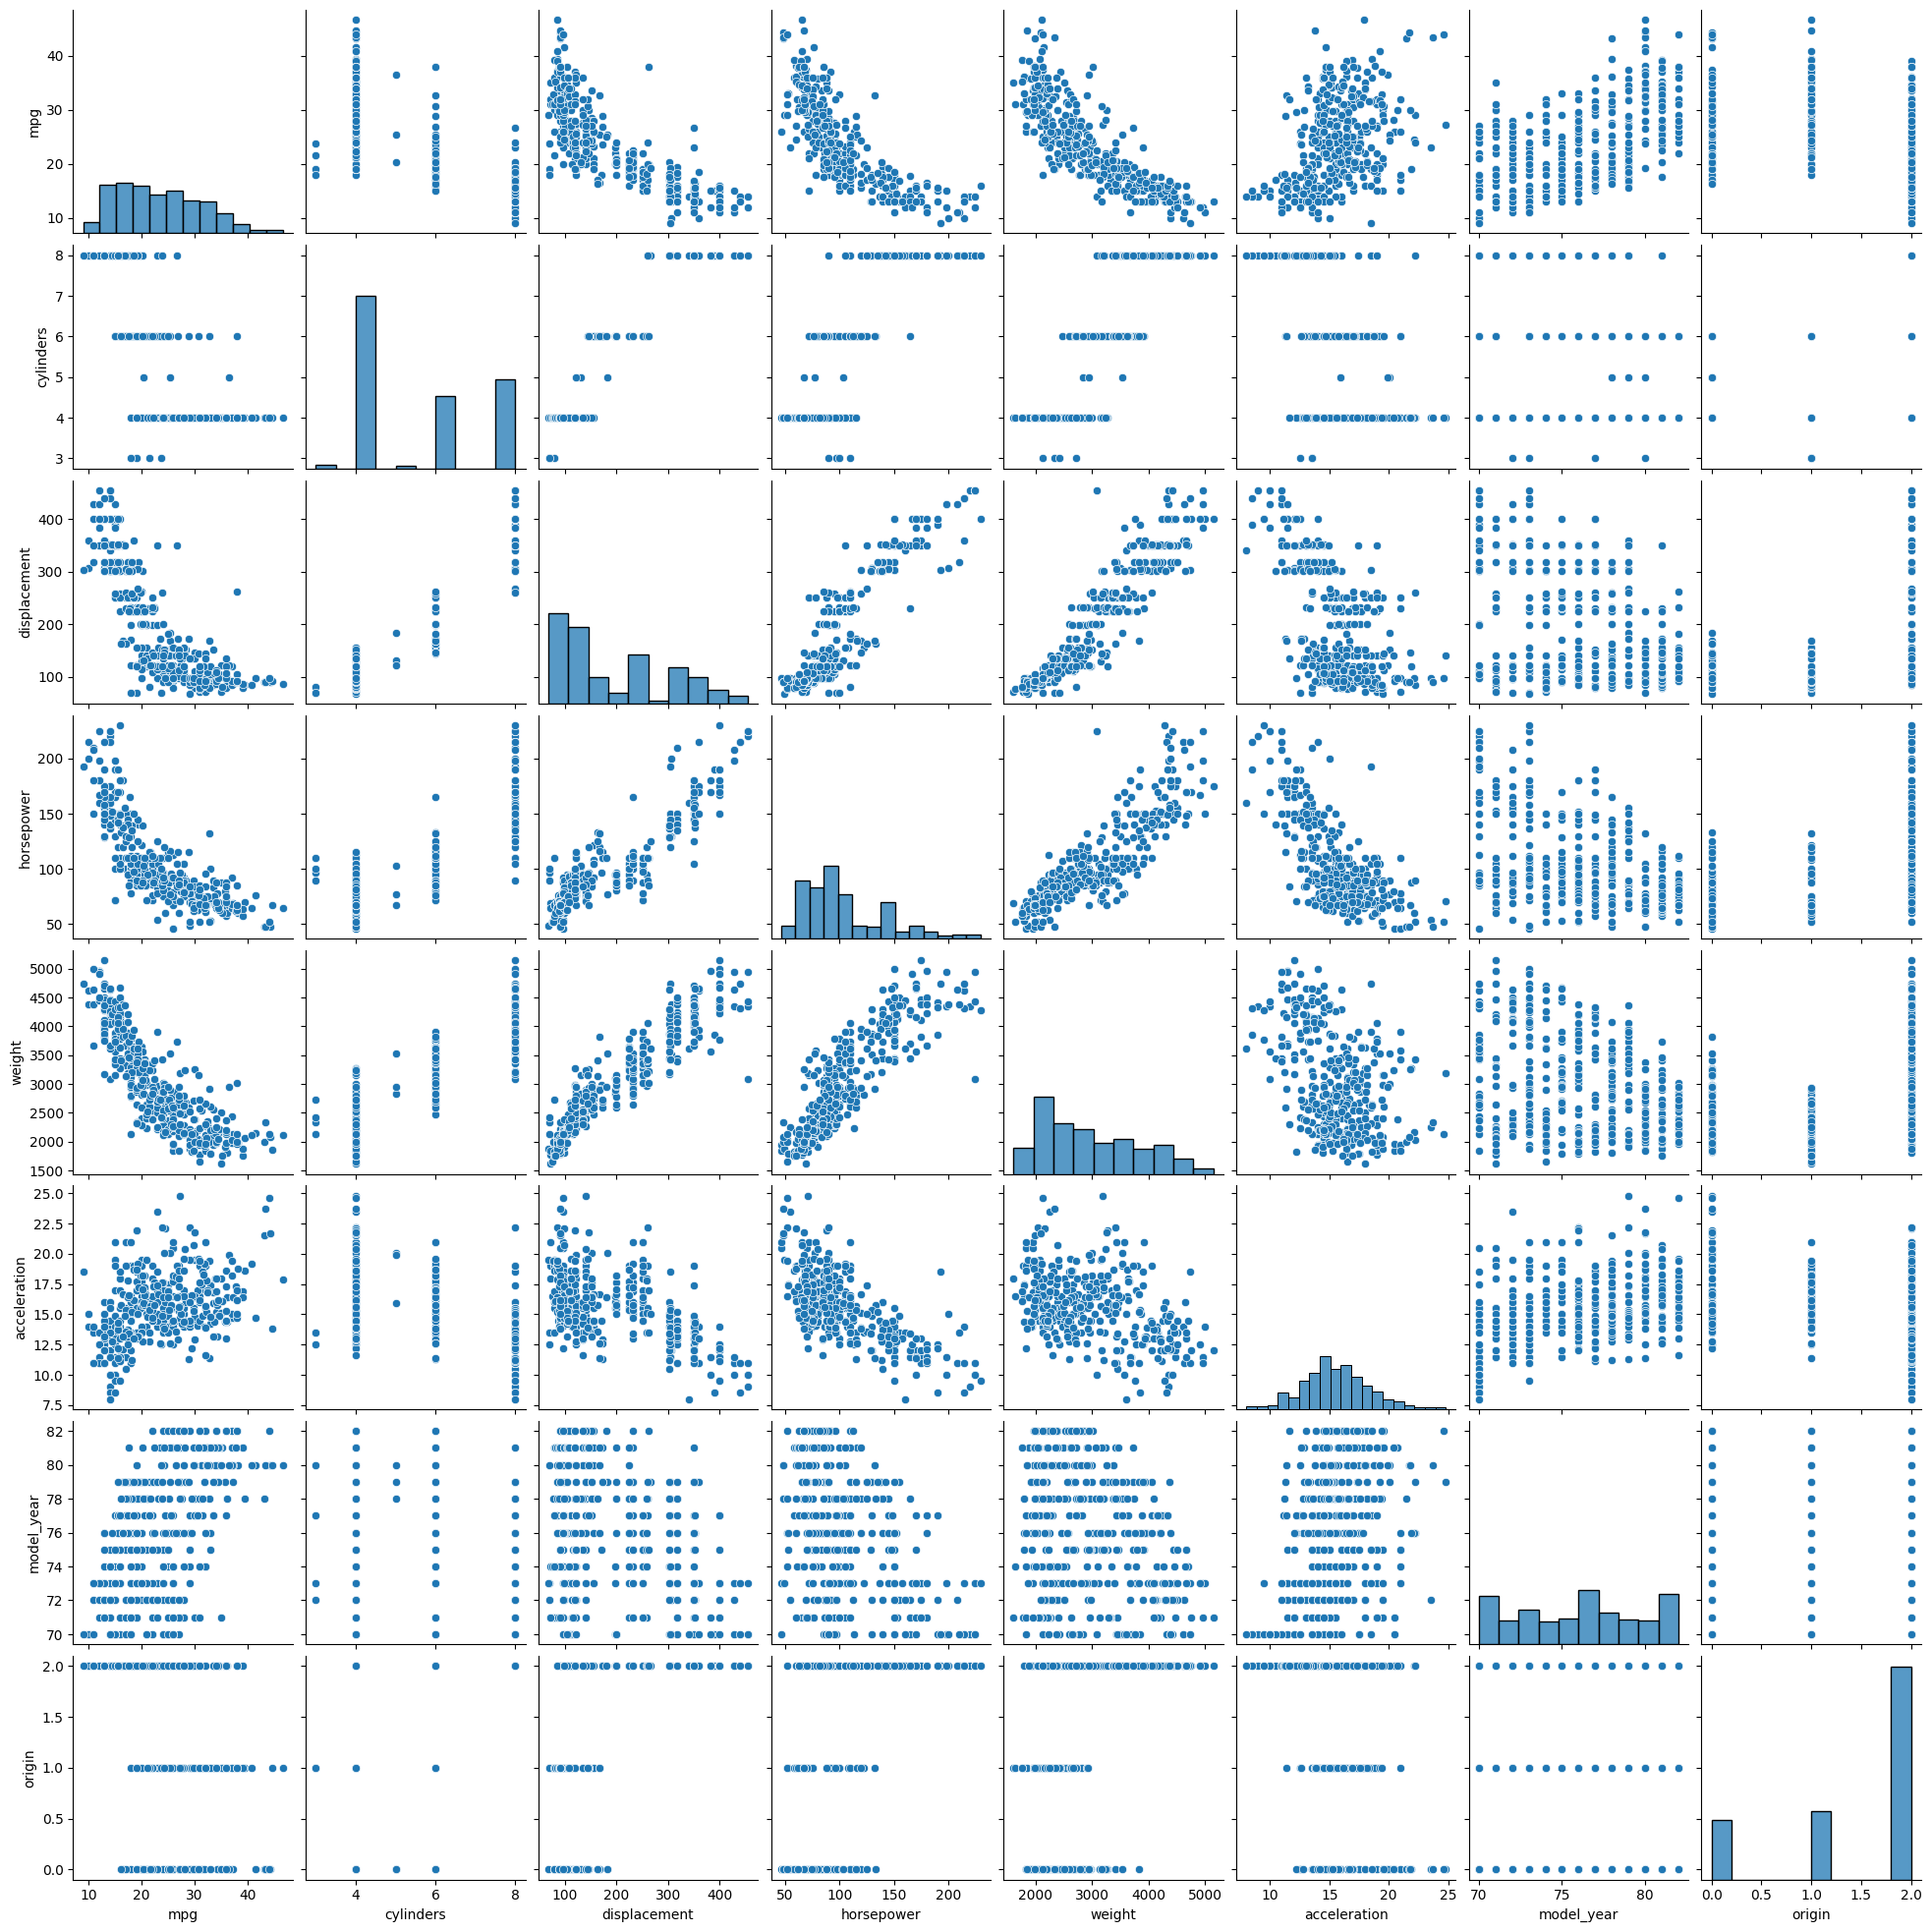

In [27]:
sns.pairplot(dfi)

In [28]:
y_train = dfi[['mpg']].values
dfi.drop('mpg', axis=1, inplace=True)
X_train = dfi.values

In [29]:
print(X_train[:5])

[[8.000e+00 3.070e+02 1.300e+02 3.504e+03 1.200e+01 7.000e+01 2.000e+00]
 [8.000e+00 3.500e+02 1.650e+02 3.693e+03 1.150e+01 7.000e+01 2.000e+00]
 [8.000e+00 3.180e+02 1.500e+02 3.436e+03 1.100e+01 7.000e+01 2.000e+00]
 [8.000e+00 3.040e+02 1.500e+02 3.433e+03 1.200e+01 7.000e+01 2.000e+00]
 [8.000e+00 3.020e+02 1.400e+02 3.449e+03 1.050e+01 7.000e+01 2.000e+00]]


In [30]:
print(y_train[:5])

[[18.]
 [15.]
 [18.]
 [16.]
 [17.]]


In [31]:
from sklearn import tree

In [32]:
model = tree.DecisionTreeRegressor()

In [33]:
model.fit(X_train, y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [34]:
y = model.predict(X_train)

In [35]:
print(y.shape)
print(y_train.shape)

(392,)
(392, 1)


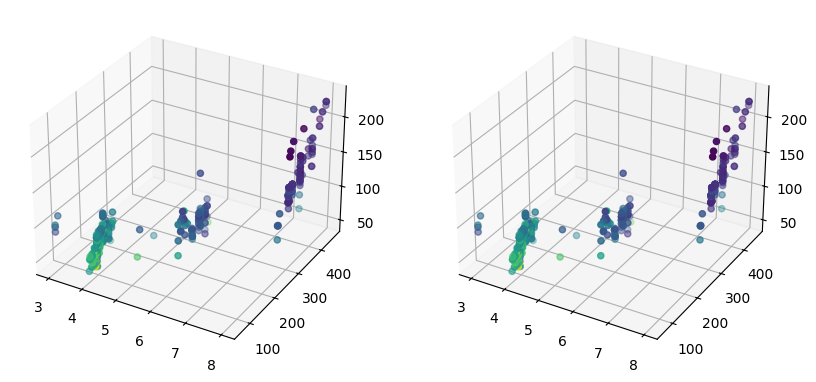

In [36]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import axes3d, Axes3D 

fig, axs = plt.subplots(ncols=2, figsize=(10, 5), subplot_kw={"projection":"3d"})
for ax, data in zip(axs, [y, y_train.reshape(-1)]):
    ax.scatter(X_train[:,0], X_train[:,1],X_train[:,2], c=data)
plt.show()

In [37]:
print(model.score(X_train, y_train))

1.0
